In [6]:
import os
import re
import sys
import time
import logging
import pickle
from pathlib import Path
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.isotonic import IsotonicRegression
import statsmodels.api as sm
from scipy.interpolate import interp1d
import multiprocessing as mp
from skbio.stats.composition import clr
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

In [7]:
import matplotlib as mpl
import matplotlib.font_manager as fm
mpl.rcParams['pdf.fonttype'] = 42
fm.fontManager.addfont("fonts/arial.ttf")
mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['lines.linewidth'] = 0.5

In [8]:
npx = pd.read_excel(
    '/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx',
    sheet_name='Npx',
    index_col='ClinicalID'
)

In [9]:
npx = npx.drop(columns=['Assay', 'Plate ID', 'QC Warning'])

In [10]:
var = pd.read_excel(
    '/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx',
    sheet_name='var',
    index_col='Assay'
)

In [11]:
lod = pd.read_excel(
    '/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx',
    sheet_name='LOD',
    index_col='Assay'
)

## Filter Missing Data

In [12]:
npx_filtered = npx[lod[lod["Missing Data freq."] < 0.25].index]

In [13]:
np.where(npx_filtered.isna())

(array([], dtype=int64), array([], dtype=int64))

## merge clinical

In [14]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [15]:
Level_counts_frac

,ClinicalID,Donor_total_cell_counts,ClinicalID_PBMC_count,ClinicalID_NDN_BAS_count,ASDC#,Adaptive NK cells#,Atypical naïve B cells#,CCR4+ CD8+ Tcm#,CCR4- CD8+ Tcm#,CD14+ cDC2#,CD177int iLDNs#,CD1C+ cDC2#,CD27+ IgD+ atypical memory B cells#,CD27+ IgD- atypical memory B cells#,CD27+ MAIT#,CD27+ Th1#,CD27+ Th17#,CD27- IgD- atypical memory B cells#,CD27- MAIT#,CD27- Th1#,CD27- Th17#,CD279+ SOX4+ Vδ1+ T cells#,CD4+ Temra#,CD56+ MAIT#,CD56bright NK cells#,CD56dim NK cells#,CD62Lhi GZMK+ Vδ2+ T cells#,CD8+ Temra#,CD8+ Treg#,CD95 memory B cells#,CILCP#,CLP#,Core classical monocytes#,DN T cells#,Early memory B cells#,GBP1+ classical monocytes#,GZMB+ CD4+ terminal effector T cells#,GZMB+ CD8+ Tem#,GZMB+ Vδ2+ T cells#,GZMK+ CD8+ Tem#,GZMK+ Vδ2+ T cells#,GZMK+ effector Vδ1+ T cells#,HLA-DRhi CD4+ Treg#,HLA-DRhi CD4+ terminal effector T cells#,HLA-DRhi CD8+ Tem#,HSC/MPP#,IGKChi Plasma cells#,IGLL5hi Plasma cells#,ILC2#,ILCP#,ISG+ classical monocytes#,Intermediate monocytes#,KLRB1+ CD4+ Treg#,KLRC2+ effector Vδ1+ T cells#,LAMP3+ DC#,MC/MCP#,MEP#,MMP8+ CD177+ iLDNs#,MMP8+ CD177+ mLDNs#,MMP9+ CD177+ iLDNs#,MPO+ CD177- iLDNs#,MPO+ mLDNs#,MPO- CD177- iLDNs#,Memory CD4+ Treg#,MkP#,Naïve B cells#,Naïve CD4+ T cells#,Naïve CD4+ Treg#,Naïve CD8+ T cells#,Naïve Vδ1+ T cells#,Non-classical monocytes#,Non-switched memory B cells#,Plamsablasts#,Proliferative CD4+ Treg#,Proliferative CD8+ memory T cells#,Proliferative DN T cells#,Proliferative NK cells#,Proliferative Vδ2+ T cells#,Proliferative cytotoxic CD4+ T cells#,Proliferative help memory T cells#,Proliferative iLDNs#,Proliferative mLDNs#,SOX4+ Vδ1+ T cells#,Switched Memory B cells#,Tfh#,Th1/Th17#,Th2#,Th22#,cDC1#,iNKT#,pDCs#,vNKT#,ASDC%_in_PBMC,Adaptive NK cells%_in_PBMC,Atypical naïve B cells%_in_PBMC,CCR4+ CD8+ Tcm%_in_PBMC,CCR4- CD8+ Tcm%_in_PBMC,CD14+ cDC2%_in_PBMC,CD177int iLDNs%_in_PBMC,CD1C+ cDC2%_in_PBMC,CD27+ IgD+ atypical memory B cells%_in_PBMC,CD27+ IgD- atypical memory B cells%_in_PBMC,CD27+ MAIT%_in_PBMC,CD27+ Th1%_in_PBMC,CD27+ Th17%_in_PBMC,CD27- IgD- atypical memory B cells%_in_PBMC,CD27- MAIT%_in_PBMC,CD27- Th1%_in_PBMC,CD27- Th17%_in_PBMC,CD279+ SOX4+ Vδ1+ T cells%_in_PBMC,CD4+ Temra%_in_PBMC,CD56+ MAIT%_in_PBMC,CD56bright NK cells%_in_PBMC,CD56dim NK cells%_in_PBMC,CD62Lhi GZMK+ Vδ2+ T cells%_in_PBMC,CD8+ Temra%_in_PBMC,CD8+ Treg%_in_PBMC,CD95 memory B cells%_in_PBMC,CILCP%_in_PBMC,CLP%_in_PBMC,Core classical monocytes%_in_PBMC,DN T cells%_in_PBMC,Early memory B cells%_in_PBMC,GBP1+ classical monocytes%_in_PBMC,GZMB+ CD4+ terminal effector T cells%_in_PBMC,GZMB+ CD8+ Tem%_in_PBMC,GZMB+ Vδ2+ T cells%_in_PBMC,GZMK+ CD8+ Tem%_in_PBMC,GZMK+ Vδ2+ T cells%_in_PBMC,GZMK+ effector Vδ1+ T cells%_in_PBMC,HLA-DRhi CD4+ Treg%_in_PBMC,HLA-DRhi CD4+ terminal effector T cells%_in_PBMC,HLA-DRhi CD8+ Tem%_in_PBMC,HSC/MPP%_in_PBMC,IGKChi Plasma cells%_in_PBMC,IGLL5hi Plasma cells%_in_PBMC,ILC2%_in_PBMC,ILCP%_in_PBMC,ISG+ classical monocytes%_in_PBMC,Intermediate monocytes%_in_PBMC,KLRB1+ CD4+ Treg%_in_PBMC,KLRC2+ effector Vδ1+ T cells%_in_PBMC,LAMP3+ DC%_in_PBMC,MC/MCP%_in_PBMC,MEP%_in_PBMC,MMP8+ CD177+ iLDNs%_in_PBMC,MMP8+ CD177+ mLDNs%_in_PBMC,MMP9+ CD177+ iLDNs%_in_PBMC,MPO+ CD177- iLDNs%_in_PBMC,MPO+ mLDNs%_in_PBMC,MPO- CD177- iLDNs%_in_PBMC,Memory CD4+ Treg%_in_PBMC,MkP%_in_PBMC,Naïve B cells%_in_PBMC,Naïve CD4+ T cells%_in_PBMC,Naïve CD4+ Treg%_in_PBMC,Naïve CD8+ T cells%_in_PBMC,Naïve Vδ1+ T cells%_in_PBMC,Non-classical monocytes%_in_PBMC,Non-switched memory B cells%_in_PBMC,Plamsablasts%_in_PBMC,Proliferative CD4+ Treg%_in_PBMC,Proliferative CD8+ memory T cells%_in_PBMC,Proliferative DN T cells%_in_PBMC,Proliferative NK cells%_in_PBMC,Proliferative Vδ2+ T cells%_in_PBMC,Proliferative cytotoxic CD4+ T cells%_in_PBMC,Proliferative help memory T cells%_in_PBMC,Proliferative iLDNs%_in_PBMC,Proliferative mLDNs%_in_PBMC,SOX4+ Vδ1+ T cells%_in_PBMC,Switched Memory B cells%_in_PBMC,Tfh%_in_PBMC,Th1/Th17%_in_PBMC,Th2%_in_PBMC,Th22%_in_PBMC,cDC1%_in_PBMC,iNKT%_in_PBMC,pDCs%_in_PBMC,vNKT%_in_PBMC,A

In [16]:
info_cols = [
        "ClinicalID", "Gender", "Age_in_Years", "Ten_year_intervals", 
        "Pregnancy", 'Pregnancy stage', "Sampling time", 
        "WBC_recalc", "NEUT#", "LYMPH#", "MONO#", "EOS#", "BASO#", "NEUT%_recalc", "LYMPH%_recalc", "MONO%_recalc", "EOS%_recalc", "BASO%_recalc",
        "RBC", "HGB", "HCT", "MCV", "MCH", 
        "MCHC", "RDW-CV", "PLT", "PDW", "MPV"
    ]

In [17]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [18]:
info.columns = ["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", 'Pregnancy stage', "Sampling time",
                "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                "NEUT%_recalc_blood", "LYMPH%_recalc_blood", "MONO%_recalc_blood", "EOS%_recalc_blood", "BASO%_recalc_blood",
                "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"]

In [19]:
np.where(info.isna())

(array([136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136,
        136, 136, 136, 136, 136, 136, 148, 148, 157, 157, 157, 157, 157,
        157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157,
        157, 157, 169, 169, 169, 169, 169, 169, 169, 169, 169, 169, 169,
        169, 169, 169, 169, 169, 169, 169, 169, 169, 314, 314, 314, 314,
        314, 314, 314, 314, 314, 314, 388, 413, 413, 413, 413, 413, 413,
        413, 413, 413, 413, 413, 413, 413, 413, 413, 413, 413, 413, 413,
        413, 451, 451, 451, 451, 451, 451, 451, 451, 451, 451, 451, 451,
        451, 451, 451, 451, 451, 451, 451, 451, 750, 750, 750, 750, 750,
        750, 750, 750, 750, 750, 772, 772, 772, 772, 772, 772, 772, 772,
        772, 772, 777, 777, 777, 777, 777, 777, 777, 777, 777, 777, 891,
        907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907,
        907, 907, 907, 907, 907, 907, 907]),
 array([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24,
   

In [20]:
all_dat = npx_filtered.join(info,how='left').dropna(axis=0,subset=["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", "Sampling time", # 'Pregnancy stage',
                                                                   "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                                                                   "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"])

In [21]:
npx_filtered.shape,info.shape,all_dat.shape

((1008, 72), (993, 27), (978, 99))

## 计算多种基于临床的炎性评分 NHANES and CHARLS
#The association between complete blood count-derived inflammatory markers and XX

In [22]:
Inflammation_index = pd.DataFrame({
        "NLR_index": all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#中性粒细胞与淋巴细胞比值（NLR）
        "PLR_index": all_dat["PLT_blood"] / all_dat["LYMPH#_blood"],#血小板淋巴细胞比值 (PLR)
        "LMR_index": all_dat["LYMPH#_blood"] / all_dat["MONO#_blood"],#淋巴细胞/单核细胞比值（LMR)
        "NPR_index": all_dat["NEUT#_blood"] / all_dat["PLT_blood"],#中性粒细胞/血小板比值（NPR)
        "SIRI_index": all_dat["MONO#_blood"] * all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#系统炎症反应指数/全身炎症反应指数（SIRI）
        "SII_index": all_dat["PLT_blood"] * all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#全身免疫炎症指数(systemic immune-inflammation index，SII)
        "AISI_index": all_dat["MONO#_blood"] * all_dat["NEUT#_blood"] * all_dat["PLT_blood"] / all_dat["LYMPH#_blood"],#全身性炎症聚合指数（aggregate index of systemic inflammation， AISI） 等于泛免疫炎症值pan-immune-inflammation value（PIV） 
    })

In [23]:
all_dat = all_dat.join(Inflammation_index)

In [24]:
all_dat

,IL8,VEGFA,CD8A,MCP-3,CDCP1,CD244,IL7,OPG,LAP TGF-beta-1,uPA,IL6,IL-17C,MCP-1,CXCL11,AXIN1,TRAIL,CXCL9,CST5,OSM,CXCL1,CCL4,CD6,SCF,IL18,SLAMF1,TGF-alpha,MCP-4,CCL11,TNFSF14,FGF-23,IL-10RA,MMP-1,LIF-R,FGF-21,CCL19,IL-10RB,IL-18R1,PD-L1,CXCL5,TRANCE,HGF,IL-12B,MMP-10,IL10,TNF,CCL23,CD5,CCL3,Flt3L,CXCL6,CXCL10,4E-BP1,SIRT2,CCL28,DNER,EN-RAGE,CD40,IFN-gamma,FGF-19,MCP-2,CASP-8,CCL25,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF-1,Gender,Age_in_Years,Ten_year_intervals,Pregnancy,Pregnancy stage,Sampling time,WBC_recalc_blood,NEUT#_blood,LYMPH#_blood,MONO#_blood,EOS#_blood,BASO#_blood,NEUT%_recalc_blood,LYMPH%_recalc_blood,MONO%_recalc_blood,EOS%_recalc_blood,BASO%_recalc_blood,RBC_blood,HGB_blood,HCT_blood,MCV_blood,MCH_blood,MCHC_blood,RDW-CV_blood,PLT_blood,PDW_blood,MPV_blood,NLR_index,PLR_index,LMR_index,NPR_index,SIRI_index,SII_index,AISI_index
ClinicalID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
D0400,6.26398,10.34428,6.69315,1.37876,3.68550,6.62041,7.37632,10.42125,6.86460,10.59654,4.06032,2.18472,10.84869,10.10148,4.98552,6.95379,7.42604,6.90517,3.23730,11.42106,7.32004,5.14144,9.13032,8.35477,2.87633,1.97124,15.71835,8.07710,4.00977,2.27620,0.70304,13.44537,4.37782,3.60375,10.23084,6.01636,8.17427,6.52495,12.28445,4.55901,8.70477,5.19593,9.28963,2.86675,2.85688,12.05323,4.97640,6.40100,9.16582,8.48015,8.65869,6.13055,7.04886,3.12882,8.93759,2.80489,12.01403,7.09936,9.89665,7.07941,4.01324,6.29889,3.00211,4.93838,2.04603,9.60703,7.02038,7.63116,7.22001,5.65135,2.34820,9.63296,Female,48.2,40-49,NO,Unavailable,Morning,4.50,2.70,1.30,0.30,0.17,0.03,60.00,28.89,6.67,3.78,0.67,4.34,137.0,40.2,92.6,31.5,340.0,13.3,288.0,16.3,7.4,2.076923,221.538462,4.333333,0.009375,0.623077,598.153846,179.446154
D0138,5.62293,10.77363,7.33753,1.32931,2.55218,6.45083,0.63760,10.16092,6.42758,10.59916,3.91695,2.11018,11.56699,8.87136,2.92404,7.47400,8.25216,6.63674,3.95233,9.12567,6.04921,6.37603,8.95193,8.42554,2.04922,1.79091,14.69661,7.32086,4.55467,2.00803,0.23529,12.46178,4.17480,5.00760,11.48501,5.82181,8.37132,6.66579,9.89161,5.49443,9.02241,5.14506,8.64853,4.33628,3.45885,11.99083,5.22787,5.32920,8.07648,7.72523,9.80443,8.05442,5.93383,2.05698,9.05777,3.26204,10.92285,7.81027,9.49782,9.84138,3.61589,6.50855,2.95706,5.49912,2.00872,9.32577,7.11506,4.87525,6.89537,5.79088,2.30830,9.66307,Male,26.2,20-29,NO,Unavailable,Morning,8.17,4.80,2.40,0.80,0.14,0.03,58.75,29.38,9.79,1.71,0.37,5.09,160.0,47.5,93.3,31.4,337.0,13.3,266.0,16.9,9.2,2.000000,110.833333,3.000000,0.018045,1.600000,532.000000,425.600000
D0836,5.80500,10.40912,7.74084,0.80529,2.87565,6.16137,0.98738,10.35615,6.59629,10.67152,1.98014,2.05479,10.65411,8.20266,4.41455,6.84058,7.77161,7.06925,3.15563,10.92708,5.67032,6.41224,9.37245,8.29844,2.86512,1.88887,15.82169,6.95211,4.34367,1.26278,0.33195,11.84289,4.31191,4.98571,11.74193,6.04509,8.77083,6.40097,12.31033,4.90195,8.55959,6.17732,7.82474,4.03813,2.58946,12.10961,5.44230,5.33682,9.14235,8.39022,7.83791,6.13560,6.55406,2.51106,9.05551,2.34998,11.48604,7.42781,10.15154,8.08507,3.49622,5.32742,2.81505,5.26091,2.08253,9.21225,7.64607,7.14411,6.72419,5.15291,2.82620,9.67478,Female,28.0,20-29,NO,Unavailable,Morning,6.01,2.90,2.60,0.30,0.16,0.05,48.25,43.26,4.99,2.66,0.83,4.34,133.0,39.2,90.3,30.6,339.0,12.1,277.0,15.9,7.6,1.115385,106.538462,8.666667,0.010469,0.334615,308.961538,92.688462
D0943,6.09244,11.32901,6.97426,1.54132,3.21980,6.91078,1.33812,11.29656,7.00345,11.29513,2.69518,2.93765,11.50449,10.08123,4.59166,7.59845,8.09212,7.58491,4.44830,11.73284,10.19583,5.87935,9.13389,9.34240,3.08744,2.68693,15.92871,7.76975,4.99800,2.24921,0.53022,12.46117,4.73830,3.74809,11.16170,6.40775,8.76344,7.11822,12.82278,4.56699,9.82622,6.05030,9.43685,3.42339,3.51996,12.86232,5.49856,8.91660,9.65964,8.80448,9.04948,7.08417,6.84602,3.40062,9.35390,2.64418,12.02845,7.74139,9.02569,8.79777,4.16800,6.75322,3.58568,5.78914,2.33690,10.03654,7.17112,7.63355,7.20266,5.74880,2

## 可视化蛋白和性别、年龄分组的关系。我认为应该要删除这些样本，节律和怀孕数据会导致异常

In [25]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

In [26]:
plt_x_list = [
    "Ten_year_intervals",
    "Pregnancy stage",
    "Sampling time",
    "Gender",
]
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
    "Pregnancy stage": [
        "First trimester",
        "Second trimester",
        "Third trimester",
        "Parturition",
    ],
    "Sampling time": ["Morning", "Evening"],
    "Gender": ["Female", "Male"],
}

In [27]:
plt_y_list = list(npx_filtered.columns) + Inflammation_index.columns.tolist()

In [28]:
def plot_box_strip(data, x, y, order, outpath):
    if data[y].dropna().empty:
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        order=order,
        palette="pastel",
        width=0.7,
        linewidth=0,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x=x,
        y=y,
        data=data,
        order=order,
        color="black",
        alpha=0.3,
        jitter=0.1,
        size=2,
        ax=ax,
    )
    ax.set_title(quick_stat_test(data, x, y), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

In [29]:
# Cell type
for plt_x in plt_x_list:
    if plt_x == "Pregnancy stage":
        plot_data = all_dat.dropna(subset=[plt_x])
    elif plt_x == "Sampling time":
        mask = all_dat.index.str.contains("_M|_E")
        plot_data = all_dat[mask]
    else:
        mask = (
            (all_dat.index.str.contains("_E"))
            | (all_dat["Pregnancy"]== "YES")
        )
        plot_data = all_dat[~mask]

    for plt_y in plt_y_list:
        fig_dir = f"/home/liyanguo/MyImmuCell/08_supp_outputs/olink/{plt_x}"
        os.makedirs(fig_dir, exist_ok=True)
        outpath = f"{fig_dir}/{plt_y}.pdf"
        data = plot_data[[plt_x, plt_y]].dropna()
        plot_box_strip(data, plt_x, plt_y, order_dict.get(plt_x, None), outpath)

/tmp/ipykernel_1987021/2793073018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1987021/2793073018.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1987021/2793073018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1987021/2793073018.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1987021/2793073018.py:5: FutureWarn

### The age distribution of Sampling times is uneven, it cannot be included in lasso

### The age distribution of pregnancy is uneven, it cannot be included in lasso

# LASSO

In [30]:
os.system('rm /home/liyanguo/MyImmuCell/10_olink/Lasso_model/*')

0

## Remove the samples that are not suitable for lasso

In [31]:
#Sampling time
mask = all_dat.index.str.contains('_E')
all_dat_filtered =  all_dat[~mask]

In [32]:
#Pregnancy
mask = all_dat_filtered['Pregnancy'] == 'NO'
all_dat_filtered = all_dat_filtered[mask]

In [33]:
all_dat_filtered = all_dat_filtered.drop(['Sampling time','Pregnancy','Pregnancy stage','Ten_year_intervals'],axis='columns')

In [34]:
all_dat_filtered.shape

(914, 102)

## Normalize NPX

In [35]:
all_dat_filtered['Gender'] = all_dat_filtered['Gender'].map({'Male': 1, 'Female': 0})

In [36]:
Gender = all_dat_filtered['Gender']
Age_in_Years = all_dat_filtered['Age_in_Years']

In [37]:
all_dat_filtered = all_dat_filtered.drop(['Gender','Age_in_Years'],axis='columns')

In [38]:
def normalize_data(data):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    return pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

In [39]:
all_dat_filtered_scaled = normalize_data(all_dat_filtered)

In [40]:
all_dat_filtered_scaled['Gender']=Gender
all_dat_filtered_scaled['Age_in_Years']=Age_in_Years

## 7/3 train_test_split

In [41]:
train_sample, test_sample = train_test_split(
    all_dat_filtered_scaled,
    test_size=0.3,
    random_state=0,
    stratify=all_dat_filtered_scaled['Gender']
)

In [42]:
train_sample.shape, test_sample.shape

((639, 102), (275, 102))

In [43]:
np.where(train_sample.isna()),np.where(test_sample.isna())

((array([], dtype=int64), array([], dtype=int64)),
 (array([], dtype=int64), array([], dtype=int64)))

In [44]:
Y_train,X_train = train_sample[['Age_in_Years']], train_sample.drop(['Age_in_Years'],axis='columns')

In [45]:
Y_test,X_test = test_sample[['Age_in_Years']], test_sample.drop(['Age_in_Years'],axis='columns')

## Bootstrap_train

In [46]:
#generate 1000 bootstrap samples
np.random.seed(0)
seed_list = np.random.randint(0, 10000, size=600)
len(seed_list)

600

In [47]:
def Train_aging_model(X_train, Y_train, seed_list, 
                          performance_CUTOFF, NPOOL=16):
    NUM_BOOTSTRAP=len(seed_list)
    
    # Bootstrap training
    pool = mp.Pool(NPOOL)
    input_list = [([X_train, Y_train, performance_CUTOFF] + [seed_list[i]]) for i in range(NUM_BOOTSTRAP)]
    coef_list = pool.starmap(Bootstrap_train, input_list)
    pool.close()
    pool.join()
    
    df_coef = pd.DataFrame(coef_list,
                           columns=["Seed", "alpha", "y_intercept"]+list(X_train.columns))
    
    return df_coef
    
def Bootstrap_train(X_train, Y_train,performance_CUTOFF, seed):
    
    #setup
    X_train_sample = X_train.sample(frac=1, replace=True, random_state=seed)#.to_numpy()
    Y_train_sample = Y_train.sample(frac=1, replace=True, random_state=seed)#.to_numpy()
    
    # LASSO grid search
    lasso = Lasso(random_state=0, tol=0.001,max_iter=20000)
    alphas = np.logspace(-1, 2, 100)
    clf_grid_search = GridSearchCV(lasso, [{'alpha': alphas}], cv=5, scoring="neg_mean_squared_error", refit=False,n_jobs=1)
    clf_grid_search.fit(X_train_sample, Y_train_sample)
    gsdf = pd.DataFrame(clf_grid_search.cv_results_)

    #pick best alpha
    best_alpha=Plot_and_pick_alpha(gsdf, performance_CUTOFF, seed, plot=False)
    
    # Retrain
    lasso = Lasso(alpha=best_alpha, random_state=0,  tol=0.001,max_iter=20000)
    lasso.fit(X_train_sample, Y_train_sample)

    # SAVE MODEL
    savefp=f"/home/liyanguo/MyImmuCell/10_olink/Lasso_model/lasso_{seed}_olink_model.pkl"
    pickle.dump(lasso, open(savefp, 'wb'))
    
    # SAVE coefficients
    coef_list = [seed, best_alpha, lasso.intercept_[0]] + list(lasso.coef_)

    return coef_list

def Plot_and_pick_alpha(gsdf, performance_CUTOFF, seed, plot=False):
    
    #pick alpha at 90-95% top performance, negative derivative (higher alpha)
    gsdf["mean_test_score_norm"] = NormalizeData(gsdf["mean_test_score"])
    gsdf["mean_test_score_norm_minus95"] = gsdf["mean_test_score_norm"]-performance_CUTOFF
    gsdf["mean_test_score_norm_minus95_abs"] = np.abs(gsdf["mean_test_score_norm_minus95"])

    #derivative of performance by alpha
    x=gsdf.param_alpha.to_numpy()
    y=gsdf.mean_test_score_norm.to_numpy()
    dx=0.1
    gsdf["derivative"] = np.gradient(y, dx)
    tmp=gsdf.loc[gsdf.derivative<0]
    if len(tmp)!=0:
        best_alpha = list(tmp.loc[tmp.mean_test_score_norm_minus95_abs == np.min(tmp.mean_test_score_norm_minus95_abs)].param_alpha)[0]
    else:
        print('no alpha with derivative <0')
        tmp2=gsdf
        best_alpha = list(tmp2.loc[tmp2.mean_test_score_norm_minus95_abs == np.min(tmp2.mean_test_score_norm_minus95_abs)].param_alpha)[0]

    # PLOT
    if plot:
        fig,axs=plt.subplots(1,2,figsize=(7,3))
        sns.scatterplot(data=gsdf, x="param_alpha", y="mean_test_score_norm", ax=axs[0])
        sns.scatterplot(data=gsdf.loc[gsdf.param_alpha==best_alpha], x="param_alpha", y="mean_test_score_norm", ax=axs[0])
        sns.scatterplot(data=gsdf, x="param_alpha", y="mean_test_score_norm", ax=axs[1])
        sns.scatterplot(data=gsdf.loc[gsdf.param_alpha==best_alpha], x="param_alpha", y="mean_test_score_norm", ax=axs[1])
        axs[0].set_xlim(-0.02,best_alpha+0.1)
        axs[0].set_ylim(0.8,1.05)
        axs[0].axvline(0.008)
        axs[0].axhline(performance_CUTOFF)
        plt.tight_layout()
        savefp=f"/home/liyanguo/MyImmuCell/10_olink/Lasso_model/lasso_{seed}_olink_model.png"
        plt.savefig(savefp)
        plt.close(fig)
    return best_alpha
    
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [48]:
%%time
dfcoef = Train_aging_model(X_train, #cell frac data after clr or log10
                          Y_train, #Age or other goal
                          seed_list, # bootstrap seed list
                          performance_CUTOFF=0.95, #heuristic for model simplification
                          NPOOL=64, #parallelize
                         )

CPU times: user 205 ms, sys: 508 ms, total: 713 ms
Wall time: 28.8 s


In [49]:
dfcoef_ = dfcoef.drop(columns=['Seed', 'alpha','y_intercept'])

In [50]:
factor = pd.DataFrame({'Bootstraps (%)':(dfcoef_ != 0).sum(axis=0) / 600 * 100, 
                    'Mean coefficient':dfcoef_.replace(0, np.nan).mean(axis=0, skipna=True)
}).sort_values('Bootstraps (%)')

/tmp/ipykernel_1987021/3851531572.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(y=factor['Mean coefficient'],


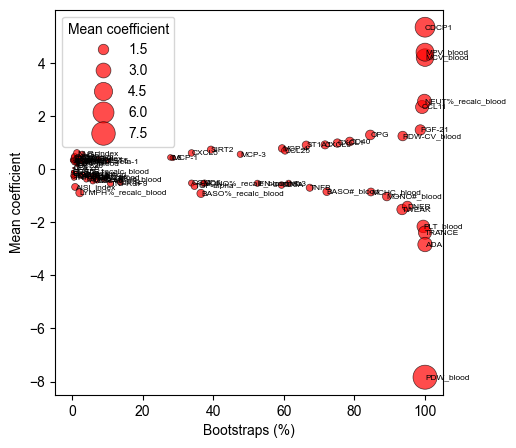

In [67]:
plt.figure(figsize=(5, 5))
sns.scatterplot(y=factor['Mean coefficient'],
                x= factor['Bootstraps (%)'],
                color='Red', alpha=0.7,
                size=abs(factor['Mean coefficient']),
                sizes=(1, 300),
                palette="coolwarm",
                edgecolor='black',linewidth=0.5
               )
plt.title('', fontsize=12)
plt.xlabel('Bootstraps (%)')
plt.ylabel('Mean coefficient')

for i in range(factor.shape[0]):
    plt.text(
        x=factor['Bootstraps (%)'].iloc[i],
        y=factor['Mean coefficient'].iloc[i],
        s=str(factor.index[i]),  # 或者 factor['Feature'].iloc[i]，取你的标签列
        fontsize=6,
        ha='left', va='center',
        color='black'
    )
    
plt.savefig('/home/liyanguo/MyImmuCell/10_olink/Bootstraps.pdf')

In [52]:
select_feature = factor[
    (factor['Bootstraps (%)'] >= 70) & 
    (factor['Mean coefficient'].abs() >= 0)
].sort_values('Bootstraps (%)')
len(select_feature)

20

In [53]:
dfcoef.to_csv('/home/liyanguo/MyImmuCell/10_olink/lasoo_train_dfcoef.csv')

## Test model

In [68]:
#import dill
from matplotlib import colors as color
import statsmodels.api as sm
from scipy.interpolate import interp1d

In [69]:
pattern = r'lasso_(\d+)_olink_model\.pkl'

seed_list_of_bootstrap = []

for filename in os.listdir('/home/liyanguo/MyImmuCell/10_olink/Lasso_model'):
    match = re.match(pattern, filename)
    if match:
        seed_ = match.group(1)
        seed_list_of_bootstrap.append(int(seed_))

In [70]:
len(seed_list_of_bootstrap)

586

In [71]:
X_test.shape,Y_test.shape

((275, 101), (275, 1))

In [78]:
def Test_all_aging_model(X_train, Y_train,
                         X_test, Y_test,
                         seed_list, 
                         performance_CUTOFF, NPOOL=16):
                                 
    NUM_BOOTSTRAP=len(seed_list)
    
    # Bootstrap training and testing
    pool = mp.Pool(NPOOL)
    input_list = [([X_train, Y_train, X_test, Y_test, performance_CUTOFF] + [seed_list[i]]) for i in range(NUM_BOOTSTRAP)]        
    pred_ages = pool.starmap(Bootstrap_test, input_list)
    pool.close()
    pool.join()

    #Organize predicte age info
    pred_age = np.mean(pred_ages, axis=0)   #mean of bootstraps
    df_Y_info = pd.concat([Y_train,Y_test]).copy()
    df_Y_info['Pred_Age']=pred_age
    
    '''
    calculate correct ∆age and rest of info with: Commentary: Correction procedures in brain-age prediction, 是在矫正预测年龄
    MileAge(adjusted) = MileAge + [Chronological_Age - (α × Chronological_Age + β)]
    '''
    #de Lange et al. (2019b) 等效于 Beheshti 
    X2 = sm.add_constant(df_Y_info['Age_in_Years'])
    model = sm.OLS(df_Y_info['Pred_Age'],X2).fit()
    df_Y_info['correct_age_deLange'] = df_Y_info['Pred_Age'] + (df_Y_info['Age_in_Years'] - (model.params.iloc[1] * df_Y_info['Age_in_Years'] + model.params.iloc[0]))

    Plot_model_age_prediction(df_Y_info, #age, pred age, and dage
                              Y_train) # train data
    
    return df_Y_info

def Bootstrap_test(X_train, Y_train, X_test, Y_test,performance_CUTOFF,seed):
    
    # READ MODEL
    savefp=f"/home/liyanguo/MyImmuCell/10_olink/Lasso_model/lasso_{seed}_olink_model.pkl"
    lasso = pickle.load(open(savefp, 'rb'))
    
    #Predict on train/test
    Ypred_train=lasso.predict(X_train)
    Ypred_test=lasso.predict(X_test)
    Ypred = np.concatenate([Ypred_train, Ypred_test])
    return Ypred

def Plot_model_age_prediction(df_Y_info, #age and pred age
                        Y_train): # age of train
    fig,axs=plt.subplots(2,2,figsize=(8,8))

    df_Y_train = df_Y_info.loc[df_Y_info.index.isin(Y_train.index)]
    df_Y_test = df_Y_info.loc[~df_Y_info.index.isin(Y_train.index)]

    #图1a: 初始模型 all samples for r calculation
    r, p = stats.pearsonr(df_Y_info.Age_in_Years, df_Y_info.Pred_Age)
    r2 = r2_score(df_Y_info['Age_in_Years'], df_Y_info['Pred_Age'])
    rmse = root_mean_squared_error(df_Y_info.Age_in_Years, df_Y_info.Pred_Age)
    mae = mean_absolute_error(df_Y_info.Age_in_Years, df_Y_info.Pred_Age)
    
    sns.regplot(
            data=df_Y_info, 
            x="Age_in_Years", y="Pred_Age", color="#1C6758",
            scatter_kws={"alpha": 0.3, "edgecolor": None},
            line_kws={"linewidth": 3}, ax=axs[0,0]
        )
    axs[0,0].set_title(f'All samples \n Pearson: r = {r:.2f}, P={p:.4f} \n r2 = {r2:.2f}; RMSE = {rmse:.2f}; MAE={mae:.2f}')
    
    #图1b: 初始模型 test sample for r calculation
    r, p = stats.pearsonr(df_Y_test.Age_in_Years, df_Y_test.Pred_Age)
    r2 = r2_score(df_Y_test['Age_in_Years'], df_Y_test['Pred_Age'])
    rmse = root_mean_squared_error(df_Y_test.Age_in_Years, df_Y_test.Pred_Age)
    mae = mean_absolute_error(df_Y_test.Age_in_Years, df_Y_test.Pred_Age)
    
    sns.regplot(
            data=df_Y_test, 
            x="Age_in_Years", y="Pred_Age", color="#1C6758",
            scatter_kws={"alpha": 0.3, "edgecolor": None},
            line_kws={"linewidth": 3}, ax=axs[0,1]
        )
    axs[0,1].set_title(f'Test samples \n Pearson: r = {r:.2f}, P={p:.4f} \n r2 = {r2:.2f}; RMSE = {rmse:.2f}; MAE={mae:.2f}')
    
    #图2a:deLange 模型 all samples for r calculation
    r, p = stats.pearsonr(df_Y_info['Age_in_Years'], df_Y_info['correct_age_deLange'])
    r2 = r2_score(df_Y_info['Age_in_Years'], df_Y_info['correct_age_deLange'])
    rmse = root_mean_squared_error(df_Y_info['Age_in_Years'], df_Y_info['correct_age_deLange'])
    mae = mean_absolute_error(df_Y_info['Age_in_Years'], df_Y_info['correct_age_deLange'])
    
    sns.regplot(
            data=df_Y_info, 
            x="Age_in_Years", y="correct_age_deLange", color="#1C6758",
            scatter_kws={"alpha": 0.3, "edgecolor": None},
            line_kws={"linewidth": 3}, ax=axs[1,0]
        )
    axs[1,0].set_title(f'All samples \n Pearson: r = {r:.2f}, P={p:.4f} \n r2 = {r2:.2f}; RMSE = {rmse:.2f}; MAE={mae:.2f}')
    
    #图2b: deLange test sample for r calculation
    r, p = stats.pearsonr(df_Y_test['Age_in_Years'], df_Y_test['correct_age_deLange'])
    r2 = r2_score(df_Y_test['Age_in_Years'], df_Y_test['correct_age_deLange'])
    rmse = root_mean_squared_error(df_Y_test['Age_in_Years'], df_Y_test['correct_age_deLange'])
    mae = mean_absolute_error(df_Y_test['Age_in_Years'], df_Y_test['correct_age_deLange'])
    
    sns.regplot(
            data=df_Y_test, 
            x="Age_in_Years", y="correct_age_deLange", color="#1C6758",
            scatter_kws={"alpha": 0.3, "edgecolor": None},
            line_kws={"linewidth": 3}, ax=axs[1,1]
        )
    axs[1,1].set_title(f'Test samples \n Pearson: r = {r:.2f}, P={p:.4f} \n r2 = {r2:.2f}; RMSE = {rmse:.2f}; MAE={mae:.2f}')


    axs[0,0].spines.right.set_visible(False)
    axs[0,0].spines.top.set_visible(False)
    axs[0,1].spines.right.set_visible(False)
    axs[0,1].spines.top.set_visible(False)
    axs[1,1].spines.right.set_visible(False)
    axs[1,1].spines.top.set_visible(False)
    axs[1,0].spines.right.set_visible(False)
    axs[1,0].spines.top.set_visible(False)
    plt.tight_layout()
    plt.show()
    fig.savefig('/home/liyanguo/MyImmuCell/10_olink/Test_all_aging_model.pdf')

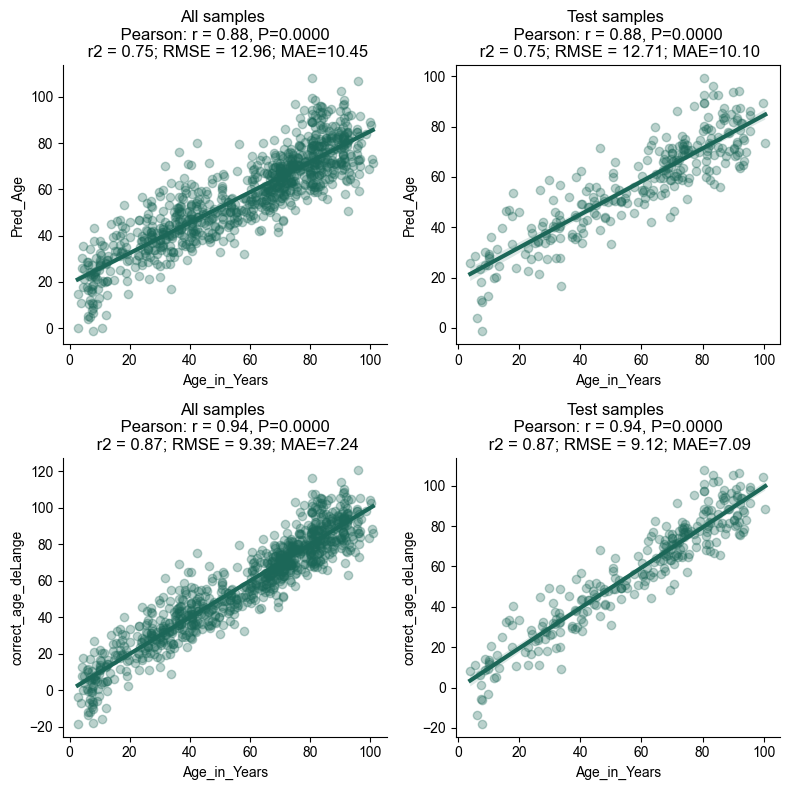

CPU times: user 717 ms, sys: 549 ms, total: 1.27 s
Wall time: 1.53 s


In [79]:
%%time
dfY = Test_all_aging_model(X_train, Y_train,
                           X_test, Y_test,
                           seed_list,
                           performance_CUTOFF=1,
                           NPOOL=64)

## LASSO all sample
#not run

# 可视化年龄和核心蛋白的热图

## Z-scored NPX

In [157]:
dfcoef = pd.read_csv('/home/liyanguo/MyImmuCell/10_olink/lasoo_train_dfcoef.csv',index_col=0)
dfcoef_ = dfcoef.drop(columns=['Seed', 'alpha','y_intercept'])
factor = pd.DataFrame({'Bootstraps (%)':(dfcoef_ != 0).sum(axis=0) / 600 * 100, 
                    'Mean coefficient':dfcoef_.replace(0, np.nan).mean(axis=0, skipna=True)
}).sort_values('Bootstraps (%)')
select_feature = factor[
    (factor['Bootstraps (%)'] >= 70) & 
    (factor['Mean coefficient'].abs() >= 0)
].sort_values('Bootstraps (%)')
len(select_feature)

20

In [169]:
factor

,Bootstraps (%),Mean coefficient
CD244,0.000000,NaN
CCL4,0.000000,NaN
CD5,0.000000,NaN
PD-L1,0.000000,NaN
CASP-8,0.000000,NaN
CX3CL1,0.000000,NaN
Gender,0.000000,NaN
SII_index,0.000000,NaN
SIRI_index,0.000000,NaN
HGB_blood,0.000000,NaN


In [158]:
df_sorted = all_dat_filtered_scaled.sort_values('Age_in_Years')[list(select_feature.sort_values('Mean coefficient').index)]

In [159]:
ages = all_dat_filtered_scaled.sort_values('Age_in_Years')['Age_in_Years']

In [160]:
df_sorted.columns

Index(['PDW_blood', 'ADA', 'TRANCE', 'PLT_blood', 'TWEAK', 'DNER',
       'MONO#_blood', 'MCHC_blood', 'BASO#_blood', 'CXCL9', 'CXCL1', 'CD40',
       'RDW-CV_blood', 'OPG', 'FGF-21', 'CCL11', 'NEUT%_recalc_blood',
       'MCV_blood', 'MPV_blood', 'CDCP1'],
      dtype='object')

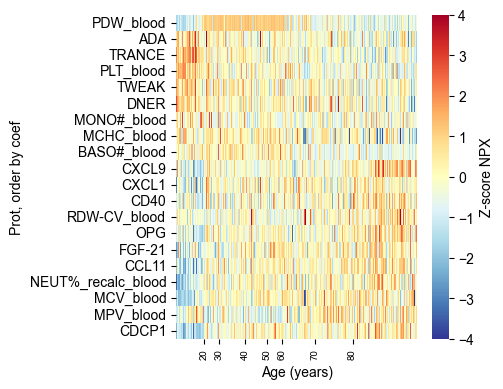

In [161]:
age_bins = [20, 30, 40, 50, 60, 70, 80]
tick_pos = [np.where(ages >= a)[0][0] for a in age_bins if np.any(ages >= a)]

plt.figure(figsize=(5, 4))
ax = sns.heatmap(
    df_sorted.T,
    center=0,
    cmap='RdYlBu_r',
    cbar_kws={'label': 'Z-score NPX'},
    vmin=-4,
    vmax=4,
    yticklabels=True
)

ax.set_xticks(tick_pos)
ax.set_xticklabels(age_bins[:len(tick_pos)], fontsize=7)

plt.xlabel('Age (years)')
plt.ylabel('Prot, order by coef')
plt.tight_layout()
plt.savefig('/home/liyanguo/MyImmuCell/10_olink/heatmap_olink.pdf')
plt.show()

## Mean Z-scored NPX

In [162]:
dfcoef = pd.read_csv('/home/liyanguo/MyImmuCell/10_olink/lasoo_train_dfcoef.csv',index_col=0)
dfcoef_ = dfcoef.drop(columns=['Seed', 'alpha','y_intercept'])
factor = pd.DataFrame({'Bootstraps (%)':(dfcoef_ != 0).sum(axis=0) / 600 * 100, 
                    'Mean coefficient':dfcoef_.replace(0, np.nan).mean(axis=0, skipna=True)
}).sort_values('Bootstraps (%)')
select_feature = factor[
    (factor['Bootstraps (%)'] >= 70) & 
    (factor['Mean coefficient'].abs() >= 0)
].sort_values('Bootstraps (%)')
len(select_feature)

20

In [163]:
df_sorted = all_dat_filtered_scaled.sort_values('Age_in_Years')[list(select_feature.sort_values('Mean coefficient').index)+['Age_in_Years']]

In [164]:
df_sorted['Ten_year_intervals'] = pd.cut(df_sorted['Age_in_Years'], 
                                  bins=[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 110], 
                                  right= False,
                                  labels=['2-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+'])
df_sorted['Ten_year_intervals'].value_counts()
df_sorted = df_sorted.drop('Age_in_Years',axis=1)

In [165]:
grouped_data = df_sorted.groupby(['Ten_year_intervals'])[list(select_feature.sort_values('Mean coefficient').index)].mean()

/tmp/ipykernel_1987021/2537565088.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_sorted.groupby(['Ten_year_intervals'])[list(select_feature.sort_values('Mean coefficient').index)].mean()


/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


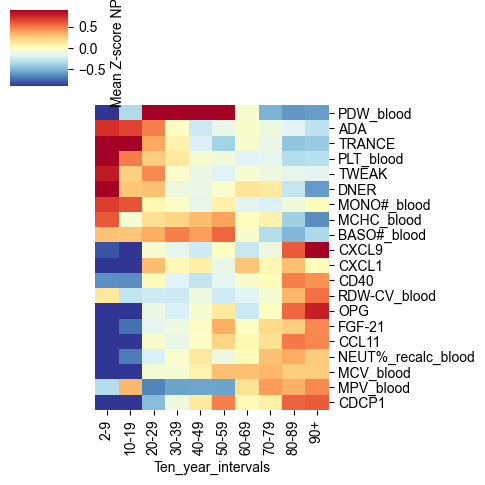

In [167]:
sns.clustermap(
    grouped_data.T,
    figsize=(5, 5),
    cmap='RdYlBu_r',
    square=True,
    vmin=-0.9, vmax=0.9,
    linewidths=0,
    cbar_kws={'label': 'Mean Z-score NPX'},
    row_cluster=False,
    col_cluster=False,
    yticklabels=True,
    xticklabels=True,
)
plt.tight_layout()
plt.savefig('/home/liyanguo/MyImmuCell/10_olink/heatmap_olink_mean.pdf',backend='pdf')
plt.show()

# 可视化年龄分组和SASP 分子水平

In [301]:
SASP = pd.read_excel("/home/liyanguo/MyImmuCell/10_olink/SenNet_BiomarkersMaster.xlsx",skiprows=0)

In [276]:
mask = SASP['Organism'].str.contains('Human')
SASP = SASP[mask]

In [277]:
mask = SASP['Senescence Hallmark'].str.contains('SASP').fillna(False)
SASP = SASP[mask]

/tmp/ipykernel_2777474/2927777500.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = SASP['Senescence Hallmark'].str.contains('SASP').fillna(False)


In [278]:
mask = SASP['Tissue'].str.contains('Circulating markers|Immune system').fillna(False)
SASP = SASP[mask].reset_index(drop=True)

In [279]:
df_sorted = all_dat_filtered_scaled.sort_values('Age_in_Years')

In [280]:
df_sorted['Ten_year_intervals'] = pd.cut(df_sorted['Age_in_Years'], 
                                  bins=[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 110], 
                                  right= False,
                                  labels=['2-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+'])
df_sorted['Ten_year_intervals'].value_counts()
df_sorted = df_sorted.drop('Age_in_Years',axis=1)

In [281]:
grouped_data = df_sorted.groupby(['Ten_year_intervals']).mean()
mask = grouped_data.columns.isin(SASP.Biomarker)
grouped_data = grouped_data.loc[:,mask]

/tmp/ipykernel_2777474/3989134586.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_sorted.groupby(['Ten_year_intervals']).mean()


/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


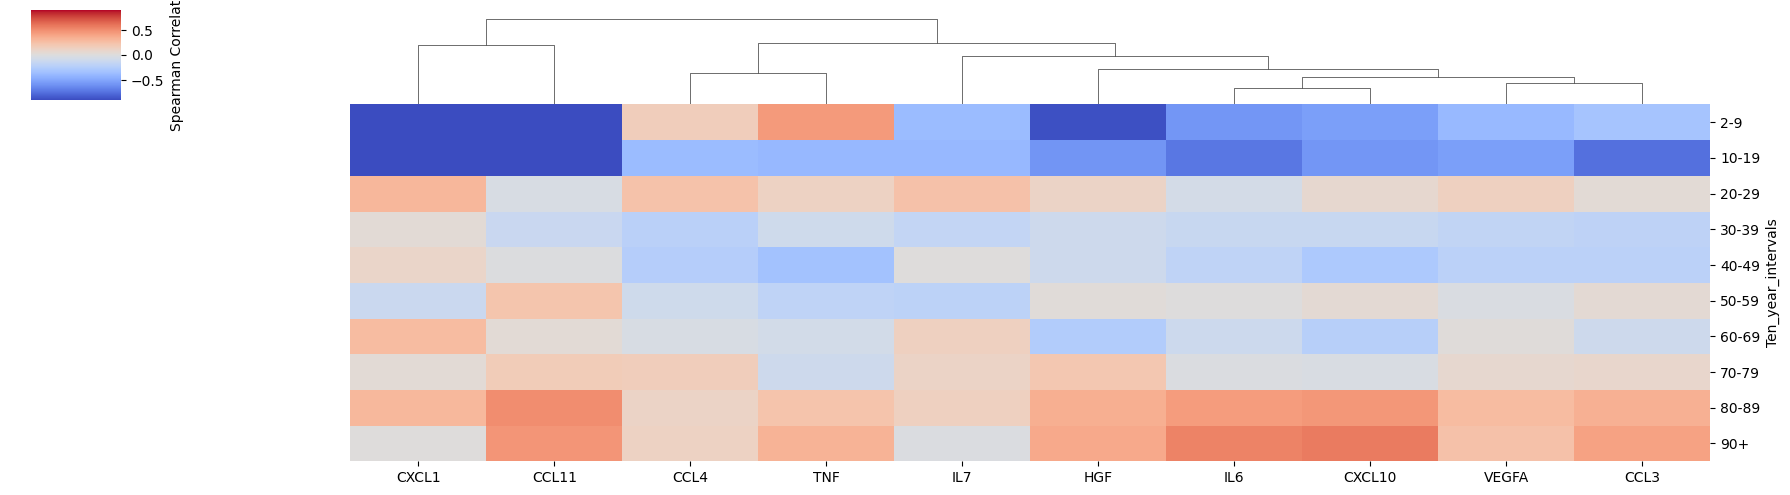

In [250]:
sns.clustermap(
    grouped_data,
    figsize=(18, 5),
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.9, vmax=0.9,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,   # 单元格边框宽度
    cbar_kws={'label': 'Spearman Correlation'},  # 颜色条标签
    row_cluster=False, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)

# Olink蛋白和蛋白的相关性

In [251]:
corr_matrix = npx_filtered.corr(method='spearman')

In [252]:
corr_matrix = npx_filtered.corr(method='pearson')

In [253]:
corr_matrix['CSF-1'].sort_values()

FGF-19            0.183853
IL-10RA           0.185620
TRANCE            0.199869
FGF-21            0.237964
CCL20             0.243891
ST1A1             0.262367
CXCL1             0.303075
IL-17C            0.313716
IFN-gamma         0.317292
CXCL5             0.320314
CD8A              0.328878
CD6               0.333878
EN-RAGE           0.339756
NT-3              0.344197
MMP-1             0.349019
SCF               0.351221
AXIN1             0.358791
4E-BP1            0.360059
CCL25             0.366961
SIRT2             0.369282
IL10              0.381160
OSM               0.396073
MMP-10            0.398765
TNFB              0.402038
CCL11             0.404784
CDCP1             0.405396
CCL19             0.408213
DNER              0.409880
STAMBP            0.410290
CASP-8            0.411173
CXCL6             0.418797
IL6               0.420350
FGF-23            0.422831
TWEAK             0.423936
CST5              0.425745
IL7               0.426664
CXCL9             0.429657
M

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 2000x1800 with 0 Axes>

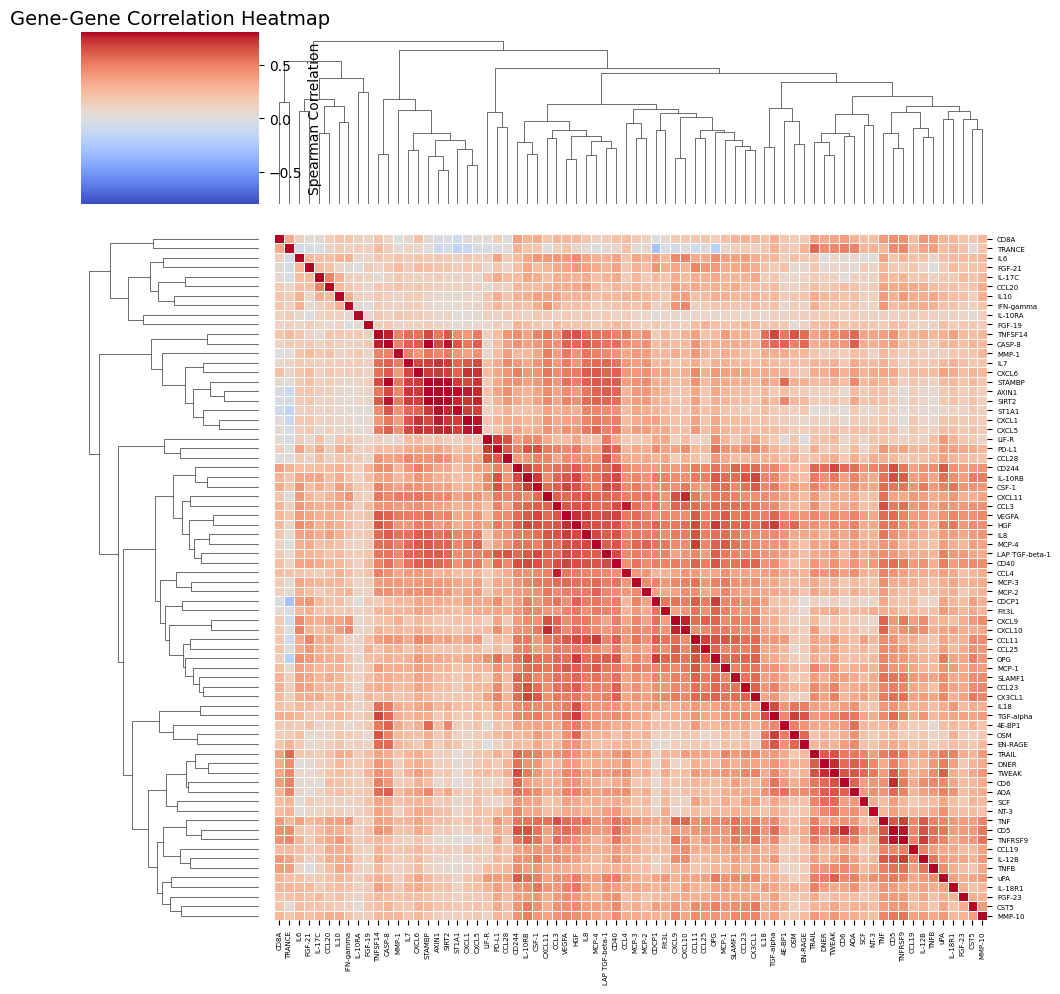

In [254]:
plt.figure(figsize=(20,18))

g = sns.clustermap(
    corr_matrix,
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.8, vmax=0.8,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0.5,   # 单元格边框宽度
    cbar_kws={'label': 'Spearman Correlation'},  # 颜色条标签
    row_cluster=True, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,        # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,        # 与Y轴一致
)

plt.title('Gene-Gene Correlation Heatmap', fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# Olink蛋白和血常规\年龄的相关性

In [ ]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_freq_table.xlsx",index_col=0)

In [470]:
info_cols = [
        "ClinicalID", "Gender", "Age_in_Years", "Ten_year_intervals", 
        "Pregnancy", 'Pregnancy stage', "Sampling time", "WBC_recalc", "NEUT#", "LYMPH#",
        "MONO#", "EOS#", "BASO#", "RBC", "HGB", "HCT", "MCV", "MCH", 
        "MCHC", "RDW-CV", "PLT", "PDW", "MPV"
    ]

In [471]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [472]:
info.columns = ["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", 'Pregnancy stage', "Sampling time", "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"]

In [473]:
np.where(info.isna())

(array([  0,   1,   2, ..., 990, 991, 992], shape=(1089,)),
 array([4, 4, 4, ..., 4, 4, 4], shape=(1089,)))

In [474]:
all_dat = npx_filtered.join(info,how='left').dropna(axis=0,subset=["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", "Sampling time", # 'Pregnancy stage',
                                                                   "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                                                                   "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"])

In [475]:
olink_cols = all_dat.columns[0:72].tolist()

In [476]:
clinical_cols = ["Age_in_Years",
               "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
               "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"]

In [477]:
corr_results = []
for olink_col in olink_cols:
    for clinical_col in clinical_cols:
        # 提取两列数据
        olink_data = all_dat[olink_col]
        clinical_data = all_dat[clinical_col]
        
        corr = olink_data.corr(clinical_data, method='spearman')
        
        corr_results.append({
            'olink_column': olink_col,
            'clinical_column': clinical_col,
            'correlation': corr
        })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [478]:
corr_df.sort_values('correlation')

,olink_column,clinical_column,correlation
663,TRANCE,Age_in_Years,-0.379037
673,TRANCE,MCV_blood,-0.288869
82,CDCP1,PLT_blood,-0.266085
674,TRANCE,MCH_blood,-0.250668
707,IL-12B,MCV_blood,-0.218015
...,...,...,...
272,CXCL9,Age_in_Years,0.461988
459,CCL11,Age_in_Years,0.462166
307,OSM,WBC_recalc_blood,0.503491
68,CDCP1,Age_in_Years,0.525420


/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 3000x3000 with 0 Axes>

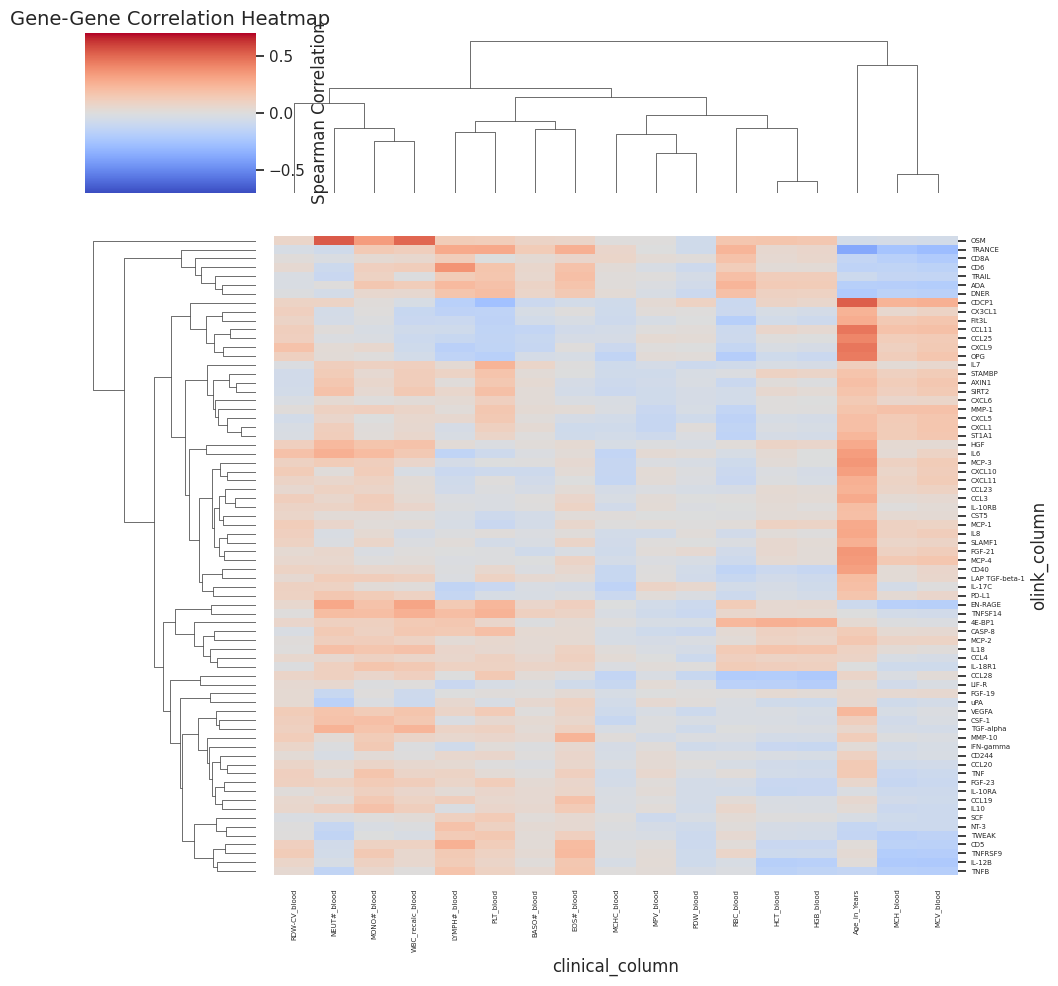

In [479]:
plt.figure(figsize=(30,30))
sns.set(style='white')
g = sns.clustermap(
    corr_df,
    pivot_kws={
        'index': 'olink_column',      # 行索引
        'columns': 'clinical_column',  # 列索引
        'values': 'correlation'# 单元格值
    },
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.7, vmax=0.7,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,   # 单元格边框宽度
    cbar_kws={'label': 'Spearman Correlation'},  # 颜色条标签
    row_cluster=True, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,        # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,        # 与Y轴一致
)
plt.title('Gene-Gene Correlation Heatmap', fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# Olink蛋白和中性粒细胞比例的关系；无需标准化

In [135]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [136]:
neu_cols = Level_counts_frac.columns[Level_counts_frac.columns.str.contains('%_in_NDN_BAS')].tolist()

In [137]:
info_cols = ["ClinicalID"] + neu_cols

In [138]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [139]:
all_dat = all_dat_filtered.join(info,how='left')

In [140]:
olink_cols = all_dat.columns[0:72].tolist()

In [141]:
corr_results = []
for olink_col in olink_cols:
    for neu_col in neu_cols:
        # 提取两列数据
        olink_data = all_dat[olink_col]
        neu_data = all_dat[neu_col]
        
        corr = olink_data.corr(neu_data, method='spearman')
        
        corr_results.append({
            'olink_column': olink_col,
            'neu_column': neu_col,
            'correlation': corr
        })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [142]:
corr_df.sort_values('correlation')

,olink_column,neu_column,correlation
576,IFN-gamma,IRF1- GBP2- NDNs%_in_NDN_BAS,-0.617377
575,IFN-gamma,IFIT2- RNF213- NDNs%_in_NDN_BAS,-0.476577
506,CXCL10,IRF1- GBP2- NDNs%_in_NDN_BAS,-0.448966
505,CXCL10,IFIT2- RNF213- NDNs%_in_NDN_BAS,-0.426335
136,CXCL11,IRF1- GBP2- NDNs%_in_NDN_BAS,-0.381609
...,...,...,...
391,TRANCE,Basophils%_in_NDN_BAS,0.188214
504,CXCL10,FOS- NDNs%_in_NDN_BAS,0.192174
570,IFN-gamma,ALPL- MARCKS- NDNs%_in_NDN_BAS,0.197715
577,IFN-gamma,MT-ATP6- MT-CO2- NDNs%_in_NDN_BAS,0.197817


In [116]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 3000x3000 with 0 Axes>

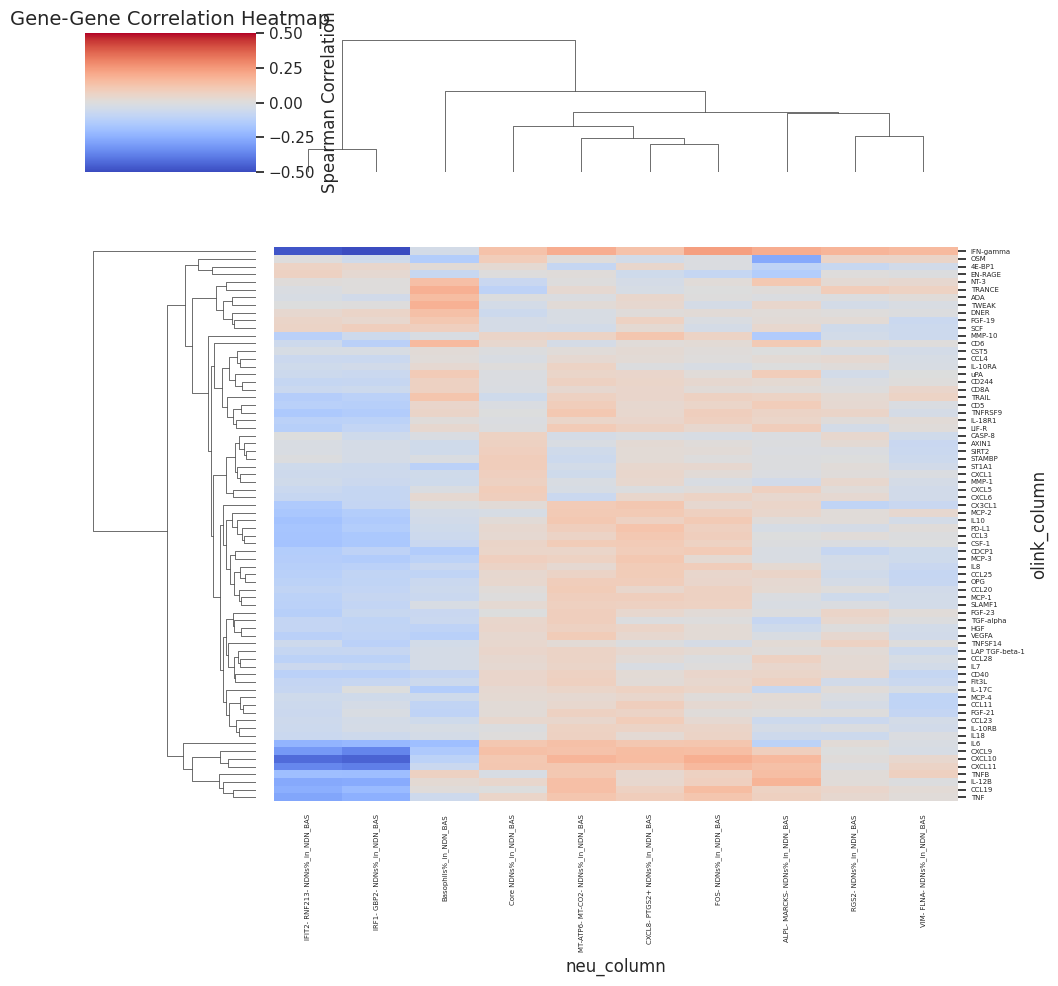

In [117]:
plt.figure(figsize=(30,30))
sns.set(style='white')
g = sns.clustermap(
    corr_df,
    pivot_kws={
        'index': 'olink_column',      # 行索引
        'columns': 'neu_column',  # 列索引
        'values': 'correlation'# 单元格值
    },
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.5, vmax=0.5,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,   # 单元格边框宽度
    cbar_kws={'label': 'Spearman Correlation'},  # 颜色条标签
    row_cluster=True, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,        # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,        # 与Y轴一致
)
plt.title('Gene-Gene Correlation Heatmap', fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

plt.savefig('gene_correlation_heatmap.pdf', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# IFN响应基因低的细胞群和老年人

In [ ]:
说明促炎和抗炎特征

IRF1-的和IFN-gamma CXCL9 CXCL10 CXCL11负相关，表明其与T细胞响应呈负相关。

In [457]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [458]:
neu_cols = Level_counts_frac.columns[Level_counts_frac.columns.str.contains('%_in_NDN_BAS')].tolist()

In [459]:
neu_cols

['ALPL- MARCKS- NDNs%_in_NDN_BAS',
 'Basophils%_in_NDN_BAS',
 'CXCL8- PTGS2+ NDNs%_in_NDN_BAS',
 'Core NDNs%_in_NDN_BAS',
 'FOS- NDNs%_in_NDN_BAS',
 'IFIT2- RNF213- NDNs%_in_NDN_BAS',
 'IRF1- GBP2- NDNs%_in_NDN_BAS',
 'MT-ATP6- MT-CO2- NDNs%_in_NDN_BAS',
 'RGS2- NDNs%_in_NDN_BAS',
 'VIM- FLNA- NDNs%_in_NDN_BAS']

In [466]:
info_cols = ["ClinicalID",'Ten_year_intervals'] + neu_cols

In [467]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [472]:
all_dat = all_dat_filtered.join(info,how='left')

In [473]:
olink_cols = all_dat.columns[0:72].tolist()

In [474]:
all_dat = all_dat[['Ten_year_intervals','IFN-gamma',]+neu_cols]

In [ ]:
all_dat

In [445]:
# 1. 年龄分组
all_dat['Age_group'] = pd.cut(all_dat['Age_in_Years'], bins=[2, 20, 59, 100], labels=['Y', 'M', 'O'])
# 2. IFN分组（中位数分割）
median_ifn = all_dat['IFN-gamma'].median()
all_dat['IFN_group'] = np.where(all_dat['IFN-gamma'] >= median_ifn, 'IFN_H', 'IFN_L')

In [476]:
all_dat.to_csv('all_dat.csv')

In [ ]:
# 设置画布大小（2行5列，子图间距合理）
plt.figure(figsize=(20, 8))  # 宽20、高8，保证每个子图足够大
plt.rcParams['font.sans-serif'] = ['Arial']  # 统一字体（避免中文乱码）

# 循环绘制10个细胞类型的子图
for i, cell in enumerate(neu_cols, 1):
    plt.subplot(2, 5, i)  # 2行5列，第i个子图
    
    # 绘制箱线图
    sns.boxplot(
        data=all_dat,
        x='Age_group',
        y=cell,
        hue='IFN_group',
        palette=['#FF6B6B', '#4ECDC4'],  # IFN高=红色，IFN低=青色（固定配色）
        width=0.6,
        linewidth=1  # 线条粗细，避免子图拥挤
    )
    
    # 子图标题（简化列名，如CD4_ratio→CD4⁺T）
    cell_name = cell.replace('_ratio', '')  # 去除_ratio后缀
    plt.title(f'{cell_name}', fontsize=12, pad=10)
    
    # 坐标轴设置
    plt.xlabel('年龄段', fontsize=10)
    plt.ylabel('占比（%）', fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    
    # 图例（仅在第一个子图显示，避免重复）
    if i == 1:
        plt.legend(title='IFN水平', loc='upper right', fontsize=9, title_fontsize=10)
    else:
        plt.legend([], [], frameon=False)  # 隐藏其他子图的图例
    
    # 网格线（仅纵轴，增强可读性）
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# 调整子图间距（避免标题/坐标轴重叠）
plt.tight_layout()

# 保存图片（高分辨率，适合论文/汇报）
#plt.savefig('10种细胞类型_IFN年龄分布_箱线图.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2777474/460592814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = all_dat.groupby(['Age_group', 'IFN_group'])[celltype].agg(


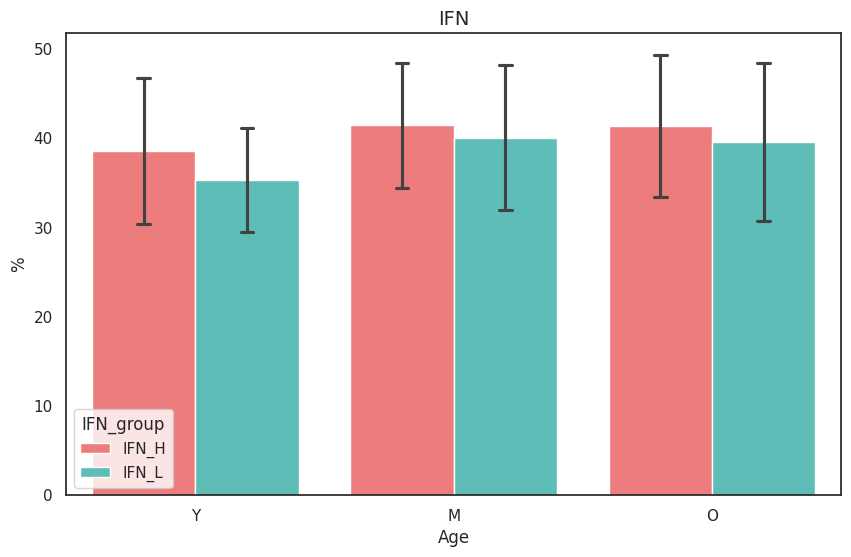

In [454]:
celltype = 'Core NDNs%_in_NDN_BAS'
desc_stats = all_dat.groupby(['Age_group', 'IFN_group'])[celltype].agg(
    均值='mean',
    标准差='std',
    中位数='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    样本量='count'
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=all_dat,
    x='Age_group',
    y=celltype,
    hue='IFN_group',
    errorbar='sd',  # 显示标准差
    palette=['#FF6B6B', '#4ECDC4'],
    capsize=0.1  # 误差线端点宽度
)
plt.title('IFN', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('%', fontsize=12)
plt.show()

# Olink蛋白和PBMC细胞比例的关系; 无需标准化

In [158]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [159]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [160]:
info_cols = ["ClinicalID"] + pbmc_cols

In [161]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [162]:
all_dat = all_dat_filtered.join(info,how='left')

In [163]:
olink_cols = all_dat.columns[0:72].tolist()

In [172]:
corr_results = []
for olink_col in olink_cols:
    for pbmc_col in pbmc_cols:
        # 提取两列数据
        olink_data = all_dat[olink_col]
        pbmc_data = all_dat[pbmc_col]
        
        corr = olink_data.corr(pbmc_data, method='pearson')
        
        corr_results.append({
            'olink_column': olink_col,
            'clinical_column': pbmc_col,
            'correlation': corr
        })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 3000x3000 with 0 Axes>

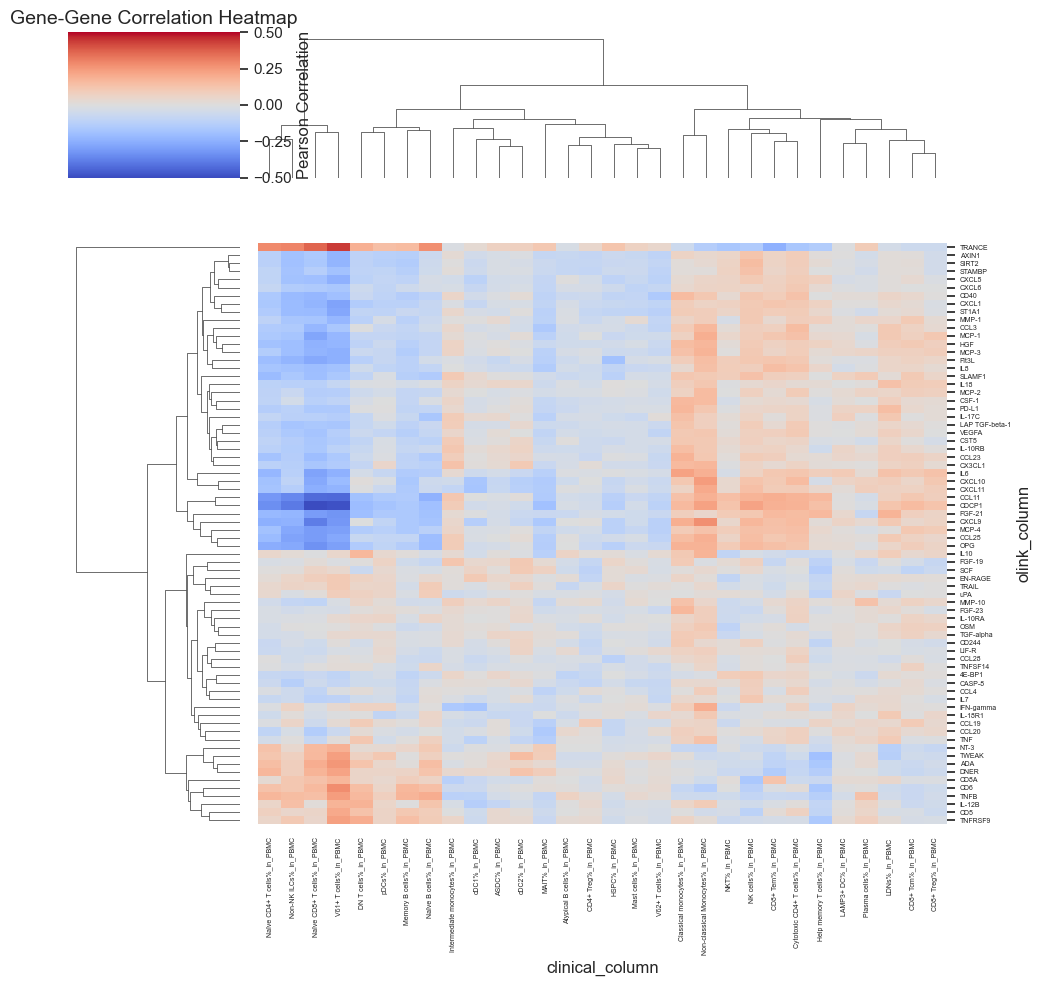

In [178]:
plt.figure(figsize=(30,30))
sns.set(style='white')
g = sns.clustermap(
    corr_df,
    pivot_kws={
        'index': 'olink_column',      # 行索引
        'columns': 'clinical_column',  # 列索引
        'values': 'correlation'# 单元格值
    },
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.5, vmax=0.5,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,   # 单元格边框宽度
    cbar_kws={'label': 'Pearson Correlation'},  # 颜色条标签
    row_cluster=True, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,        # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,        # 与Y轴一致
)
plt.title('Gene-Gene Correlation Heatmap', fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

plt.savefig('../08_supp_outputs/olink/gene_correlation_heatmap.pdf')  # 保存为高清图片
plt.show()

In [ ]:
# 炎症评分：细胞比例，蛋白质

In [ ]:
# 使用细胞比例和炎症指标的相关性，代表细胞的炎症评分？合适吗
# 不同细胞的炎性指标和基因都是不同的，使用与表型的相关性

In [180]:
all_dat.columns

Index(['IL8', 'VEGFA', 'CD8A', 'MCP-3', 'CDCP1', 'CD244', 'IL7', 'OPG',
       'LAP TGF-beta-1', 'uPA',
       ...
       'Naïve CD4+ T cells%_in_PBMC', 'Naïve CD8+ T cells%_in_PBMC',
       'Non-NK ILCs%_in_PBMC', 'Non-classical Monocytes%_in_PBMC',
       'Plasma cells%_in_PBMC', 'Vδ1+ T cells%_in_PBMC',
       'Vδ2+ T cells%_in_PBMC', 'cDC1%_in_PBMC', 'cDC2%_in_PBMC',
       'pDCs%_in_PBMC'],
      dtype='object', length=132)

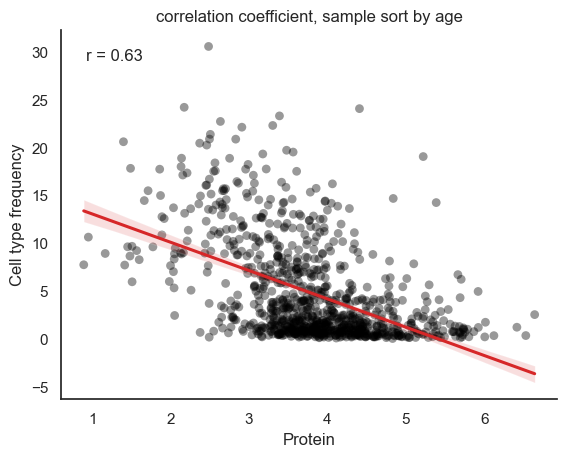

In [181]:
sns.regplot(
    data=all_dat,
    x="CDCP1",
    y='Naïve CD8+ T cells%_in_PBMC',
    scatter_kws={
        "color": "black",
        "alpha": 0.4,
        "s": 40,
        "edgecolor": "none"
    },
    line_kws={
        "color": "#D62728",
        "linewidth": 2.2
    }
)
plt.text(
    0.05, 0.95,
    f"r = 0.63",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.title(f"correlation coefficient, sample sort by age")
plt.xlabel("Protein")
plt.ylabel("Cell type frequency")
sns.despine()
plt.savefig('/home/liyanguo/MyImmuCell/08_supp_outputs/olink/CDCP1_Naive_CD8.pdf')
plt.show()

# Inflammation_index和Olink相关性

In [353]:
Level_counts_frac = pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [354]:
info_cols = [
        "ClinicalID", "Gender", "Age_in_Years", "Ten_year_intervals", 
        "Pregnancy", 'Pregnancy stage', "Sampling time", "WBC_recalc", "NEUT#", "LYMPH#",
        "MONO#", "EOS#", "BASO#", "RBC", "HGB", "HCT", "MCV", "MCH", 
        "MCHC", "RDW-CV", "PLT", "PDW", "MPV"
    ]

In [355]:
info = Level_counts_frac[info_cols].set_index("ClinicalID").drop_duplicates()

In [356]:
info.columns = ["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", 'Pregnancy stage', "Sampling time", "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"]

In [357]:
np.where(info.isna())

(array([136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136,
        136, 148, 148, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157,
        157, 157, 157, 157, 157, 169, 169, 169, 169, 169, 169, 169, 169,
        169, 169, 169, 169, 169, 169, 169, 314, 314, 314, 314, 314, 314,
        314, 314, 314, 314, 388, 413, 413, 413, 413, 413, 413, 413, 413,
        413, 413, 413, 413, 413, 413, 413, 451, 451, 451, 451, 451, 451,
        451, 451, 451, 451, 451, 451, 451, 451, 451, 750, 750, 750, 750,
        750, 750, 750, 750, 750, 750, 772, 772, 772, 772, 772, 772, 772,
        772, 772, 772, 777, 777, 777, 777, 777, 777, 777, 777, 777, 777,
        891, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 907,
        907, 907, 907]),
 array([ 7,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 20, 21,  7,
         8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,  7,  8,  9,
        10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 12, 13, 14, 15, 16,
        17, 18, 1

In [358]:
all_dat = npx_filtered.join(info,how='left').dropna(axis=0,subset=["Gender", "Age_in_Years", "Ten_year_intervals","Pregnancy", "Sampling time", # 'Pregnancy stage',
                                                                   "WBC_recalc_blood", "NEUT#_blood", "LYMPH#_blood","MONO#_blood", "EOS#_blood", "BASO#_blood", 
                                                                   "RBC_blood", "HGB_blood", "HCT_blood", "MCV_blood", "MCH_blood", "MCHC_blood", "RDW-CV_blood", "PLT_blood", "PDW_blood", "MPV_blood"])

In [359]:
npx_filtered.shape,info.shape,all_dat.shape

((1008, 72), (993, 22), (978, 94))

## 计算多种基于临床的炎性评分 NHANES and CHARLS
#The association between complete blood count-derived inflammatory markers and XX

In [360]:
Inflammation_index = pd.DataFrame({
        "NLR_index": all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#中性粒细胞与淋巴细胞比值（NLR）
        "PLR_index": all_dat["PLT_blood"] / all_dat["LYMPH#_blood"],#血小板淋巴细胞比值 (PLR)
        "LMR_index": all_dat["LYMPH#_blood"] / all_dat["MONO#_blood"],#淋巴细胞/单核细胞比值（LMR)
        "NPR_index": all_dat["NEUT#_blood"] / all_dat["PLT_blood"],#中性粒细胞/血小板比值（NPR)
        "SIRI_index": all_dat["MONO#_blood"] * all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#系统炎症反应指数/全身炎症反应指数（SIRI）
        "SII_index": all_dat["PLT_blood"] * all_dat["NEUT#_blood"] / all_dat["LYMPH#_blood"],#全身免疫炎症指数(systemic immune-inflammation index，SII)
        "AISI_index": all_dat["MONO#_blood"] * all_dat["NEUT#_blood"] * all_dat["PLT_blood"] / all_dat["LYMPH#_blood"],#全身性炎症聚合指数（aggregate index of systemic inflammation， AISI） 等于泛免疫炎症值pan-immune-inflammation value（PIV） 
    })

In [361]:
all_dat = all_dat.join(Inflammation_index)

In [362]:
olink_cols = all_dat.columns[0:72].tolist()
len(olink_cols)

72

In [363]:
Inflammation_cols = ["NLR_index","PLR_index","LMR_index","NPR_index","SIRI_index","SII_index","AISI_index"]

In [364]:
corr_results = []
for olink_col in olink_cols:
    for Inflammation_col in Inflammation_cols:
        # 提取两列数据
        olink_data = all_dat[olink_col]
        Inflammation_data = all_dat[Inflammation_col]
        
        corr = olink_data.corr(Inflammation_data, method='spearman')
        
        corr_results.append({
            'olink_column': olink_col,
            'Inflammation_column': Inflammation_col,
            'correlation': corr
        })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [365]:
corr_df.sort_values('correlation')

,olink_column,Inflammation_column,correlation
72,IL6,LMR_index,-0.324735
147,CD6,NLR_index,-0.323016
273,TRANCE,NLR_index,-0.247323
148,CD6,PLR_index,-0.239572
322,CD5,NLR_index,-0.231709
...,...,...,...
131,OSM,SII_index,0.351305
74,IL6,SIRI_index,0.368617
129,OSM,NPR_index,0.381048
130,OSM,SIRI_index,0.434899


/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 3000x3000 with 0 Axes>

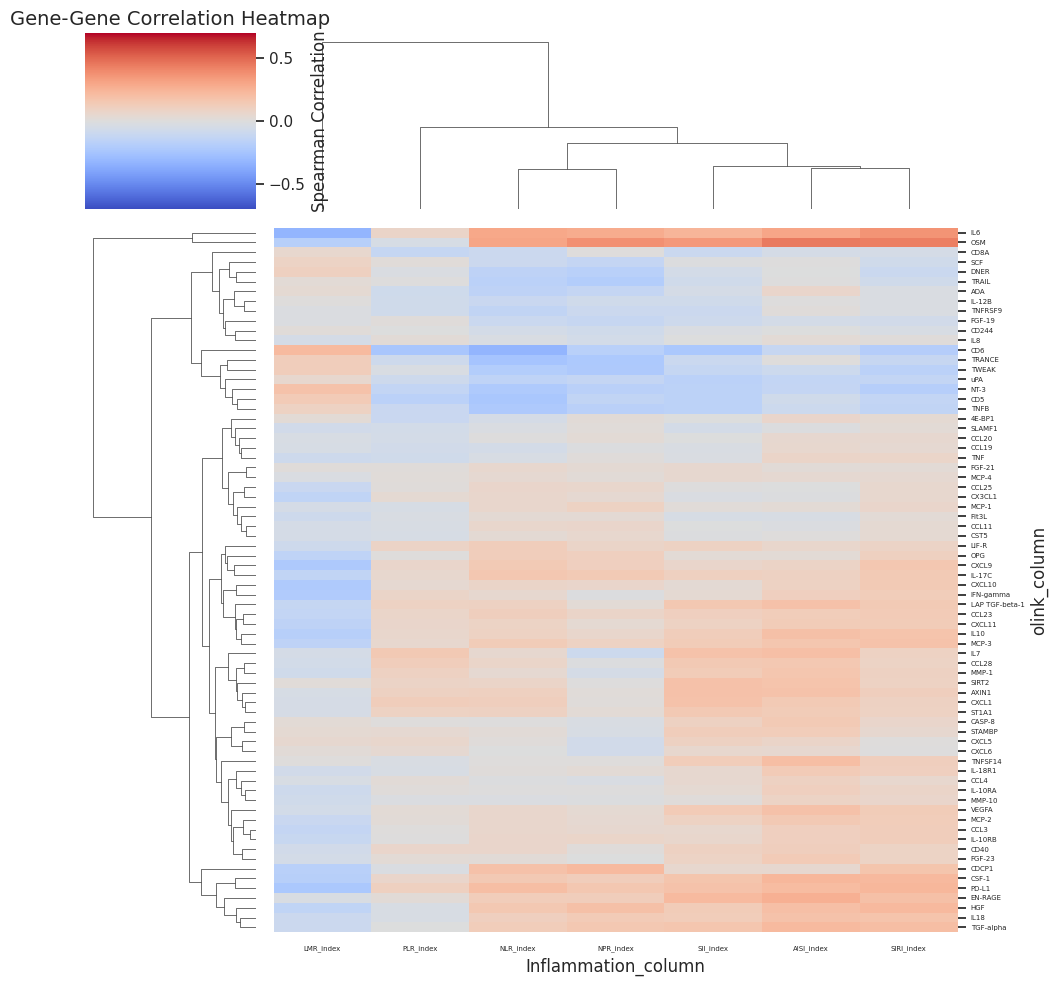

In [366]:
plt.figure(figsize=(30,30))
sns.set(style='white')
g = sns.clustermap(
    corr_df,
    pivot_kws={
        'index': 'olink_column',      # 行索引
        'columns': 'Inflammation_column',  # 列索引
        'values': 'correlation'# 单元格值
    },
    cmap='coolwarm',  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,      # 单元格为正方形
    vmin=-0.7, vmax=0.7,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,   # 单元格边框宽度
    cbar_kws={'label': 'Spearman Correlation'},  # 颜色条标签
    row_cluster=True, # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,        # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,        # 与Y轴一致
)
plt.title('Gene-Gene Correlation Heatmap', fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# 细胞基因表达和Olink关联

In [515]:
import scanpy as sc

In [516]:
adata = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Pseudobulk_samplewise_scRNA_count_Classification_L4.h5ad')

In [517]:
adata.X = adata.layers['sum'].copy()

In [518]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [519]:
exp = pd.DataFrame(adata.X).copy()

In [520]:
exp.index = adata.obs_names
exp.columns = adata.var_names
exp['ClinicalID'] = adata.obs.SampleID.str.replace(r'_Rep[123]', '', regex=True)
exp['Celltype'] = adata.obs_names.str.split('_').str[0]

In [521]:
exp = exp.merge(npx_filtered, left_on='ClinicalID', right_index=True, how='inner')

In [522]:
olink_gene = pd.read_csv("olink.csv")
existing_cols = olink_gene['Gene'][olink_gene['Gene'].isin(exp.columns)].unique()  # 去重
olink_gene = olink_gene[olink_gene['Gene'].isin(existing_cols)]

In [523]:
corr_results = []
for celltype in np.unique(exp['Celltype']).tolist():
    exp_sub = exp.loc[exp['Celltype']==celltype]
    for gene in olink_gene['Gene'].tolist():
        prot = olink_gene['Prot'][olink_gene['Gene']==gene].iloc[0]
        gene_data = exp_sub[gene]
        prot_data = exp_sub[prot]
        
        corr = gene_data.corr(prot_data, method='spearman')
        
        corr_results.append({
            'Celltype': celltype,
            'gene_column': gene,
            'prot_column': prot,
            'correlation': corr
        })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [524]:
corr_df.sort_values('correlation',ascending=False)

,Celltype,gene_column,prot_column,correlation
2101,Naïve CD4+ T cells,FLT3LG,Flt3L,0.210703
942,CXCR4- CXCL8- mature neutrophils,CD274,PD-L1,0.203870
2926,Tfh,FLT3LG,Flt3L,0.202029
1146,GBP1+ classical monocytes,S100A12,EN-RAGE,0.195888
1008,Core mature neutrophils,CD274,PD-L1,0.191357
...,...,...,...,...
3136,vNKT,CCL7,MCP-3,NaN
3145,vNKT,CCL13,MCP-4,NaN
3148,vNKT,MMP1,MMP-1,NaN
3150,vNKT,FGF21,FGF-21,NaN


In [525]:
corr_df.sort_values('correlation',ascending=True)

,Celltype,gene_column,prot_column,correlation
413,CD27+ Th17,IL18R1,IL-18R1,-0.300409
2921,Tfh,IL18R1,IL-18R1,-0.226007
2954,Th1/Th17,IL18R1,IL-18R1,-0.215245
1271,GZMK+ CD8+ Tem,IL18R1,IL-18R1,-0.196363
545,CD27- Th17,IL18R1,IL-18R1,-0.194602
...,...,...,...,...
3136,vNKT,CCL7,MCP-3,NaN
3145,vNKT,CCL13,MCP-4,NaN
3148,vNKT,MMP1,MMP-1,NaN
3150,vNKT,FGF21,FGF-21,NaN


In [ ]:
corr_results = []
for celltype in np.unique(exp['Celltype']).tolist():
    exp_sub = exp.loc[exp['Celltype']==celltype]
    for gene in adata.var_names.tolist():
        for prot in olink_gene['Prot'].tolist():
            gene_data = exp_sub[gene]
            prot_data = exp_sub[prot]
            
            corr = gene_data.corr(prot_data, method='spearman')
            
            corr_results.append({
                'Celltype': celltype,
                'gene_column': gene,
                'prot_column': prot,
                'correlation': corr
            })

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [ ]:
corr_df.sort_values('correlation',ascending=False)

In [ ]:
corr_df.sort_values('correlation',ascending=True)